In [1]:
import kagglehub
import json
import os
import numpy as np
import tensorflow as tf
import keras_cv
from PIL import Image

2026-05-23 09:24:53.229579: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 09:24:53.279432: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-23 09:24:53.279470: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-23 09:24:53.279499: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-23 09:24:53.287356: I tensorflow/core/platform/cpu_feature_g

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Using TensorFlow backend


# Dataset Preprocessing

In [2]:
path = kagglehub.dataset_download("solesensei/solesensei_bdd100k", output_dir="/workspace/data")

print("Path to dataset files:", path)

Path to dataset files: /workspace/data


In [3]:
CLASSES = ["person", "car", "rider", "bicycle", "motorcycle", "bus", "caravan", "truck"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

In [5]:
MAX_BOXES = 100

In [6]:
def parse_entry(entry, images_dir, image_size):
    img_path = os.path.join(images_dir, entry["name"])

    valid_labels = [
        l for l in entry.get("labels", [])
        if l["category"] in CLASS_TO_IDX and "box2d" in l
    ]

    if not valid_labels or not os.path.exists(img_path):
        return None

    img = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img.size
    img = img.resize(image_size)
    img_array = np.array(img, dtype=np.float32) / 255.0

    scale_x = image_size[0] / orig_w
    scale_y = image_size[1] / orig_h

    img_boxes = []
    img_classes = []

    for label in valid_labels:
        b = label["box2d"]
        img_boxes.append([
            b["x1"] * scale_x,
            b["y1"] * scale_y,
            b["x2"] * scale_x,
            b["y2"] * scale_y
        ])
        img_classes.append(float(CLASS_TO_IDX[label["category"]]))

    return img_array, img_boxes, img_classes


def make_generator(json_path, images_dir, image_size=(640, 640)):
    with open(json_path) as f:
        data = json.load(f)

    def generator():
        for entry in data:
            valid_labels = [
                l for l in entry.get("labels", [])
                if l["category"] in CLASS_TO_IDX and "box2d" in l
            ]
            if not valid_labels:
                continue

            img_path = os.path.join(images_dir, entry["name"])
            if not os.path.exists(img_path):
                continue

            # Yield path + annotations, NOT the loaded image
            img_boxes   = np.zeros((MAX_BOXES, 4), dtype=np.float32)
            img_classes = np.full((MAX_BOXES,), -1, dtype=np.float32)

            orig_w, orig_h = 1280, 720  # BDD100K is always this size
            scale_x = image_size[0] / orig_w
            scale_y = image_size[1] / orig_h

            for i, label in enumerate(valid_labels[:MAX_BOXES]):
                b = label["box2d"]
                img_boxes[i] = [
                    b["x1"] * scale_x,
                    b["y1"] * scale_y,
                    b["x2"] * scale_x,
                    b["y2"] * scale_y
                ]
                img_classes[i] = CLASS_TO_IDX[label["category"]]

            yield img_path.encode(), img_boxes, img_classes  # path as bytes

    return generator


def load_image(img_path, boxes, classes, image_size=(640, 640)):
    # This runs in TF graph, parallelizable
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, image_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, boxes, classes


def make_dataset(json_path, images_dir, batch_size=16, image_size=(640, 640)):
    generator = make_generator(json_path, images_dir, image_size)

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(),            dtype=tf.string),   # path
            tf.TensorSpec(shape=(MAX_BOXES, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(MAX_BOXES,),   dtype=tf.float32),
        )
    )

    def format_for_kerascv(image, boxes, classes):
        return {
            "images": image,
            "bounding_boxes": {
                "boxes":   boxes,
                "classes": classes
            }
        }

    return (dataset
        .shuffle(512)
        .repeat()
        .map(lambda p, b, c: load_image(p, b, c, image_size),
             num_parallel_calls=tf.data.AUTOTUNE)   # parallel image loading
        .batch(batch_size)
        .map(format_for_kerascv, num_parallel_calls=tf.data.AUTOTUNE)
        .prefetch(tf.data.AUTOTUNE))

In [7]:
train_ds = make_dataset(
    "/tf/data/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json",
    "/tf/data/bdd100k/bdd100k/images/100k/train",
    batch_size=16
)

val_ds = make_dataset(
    "/tf/data/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json",
    "/tf/data/bdd100k/bdd100k/images/100k/val",
    batch_size=16
)

2026-05-23 09:25:39.799978: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22391 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:d2:00.0, compute capability: 8.6


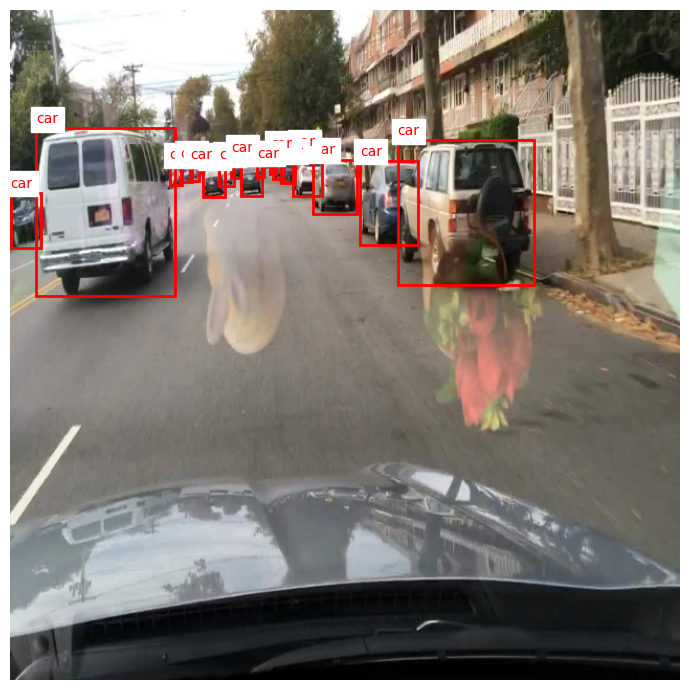

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

CLASS_NAMES = ["person", "car", "rider", "bicycle", "motorcycle", "bus"]

def visualize_sample(dataset, class_names=CLASS_NAMES):
    sample = next(iter(dataset))
    
    image   = sample["images"][0].numpy()
    boxes   = sample["bounding_boxes"]["boxes"][0].numpy()
    classes = sample["bounding_boxes"]["classes"][0].numpy()

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(image)

    for box, cls in zip(boxes, classes):
        if cls == -1:  # skip padding
            continue
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), w, h,
                                  linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, class_names[int(cls)],
                color='red', fontsize=10, backgroundcolor='white')

    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_sample(train_ds)

# Model Training

In [9]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="model_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [10]:
backbone = keras_cv.models.YOLOV8Backbone.from_preset( # using coco weights
    "yolo_v8_xs_backbone_coco",
    load_weights=True
)

model = keras_cv.models.YOLOV8Detector(
    num_classes=len(CLASS_TO_IDX),
    bounding_box_format="xyxy",
    backbone=backbone,
    fpn_depth=1
)

model.backbone.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3, global_clipnorm=10.0), classification_loss="binary_crossentropy", box_loss="ciou")
model.fit(train_ds, epochs=10, steps_per_epoch=(10000//16), validation_data=val_ds, validation_steps=(1000//16), callbacks=[checkpoint])

model.backbone.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4, global_clipnorm=10.0), classification_loss="binary_crossentropy", box_loss="ciou")
model.fit(train_ds, epochs=20, initial_epoch=10, steps_per_epoch=(10000//16), validation_data=val_ds, validation_steps=(1000//16), callbacks=[checkpoint])

/usr/local/lib/python3.11/dist-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/usr/local/lib/python3.11/dist-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids


Epoch 1/10


2026-05-23 09:26:14.216427: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-23 09:26:14.741112: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8905
2026-05-23 09:26:14.886789: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-23 09:26:19.548649: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x74e92197ab70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-23 09:26:19.548682: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2026-05-23 09:26:19.553169: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-23 09:26:19.648323: I ./tensorflow/compiler/jit/device_compiler.h:

625/625 [==============================] - ETA: 0s - loss: 21.1346 - box_loss: 3.1585 - class_loss: 17.9761
Epoch 1: saving model to model_01.keras


/usr/local/lib/python3.11/dist-packages/keras_cv/src/models/task.py:43: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/usr/local/lib/python3.11/dist-packages/keras_cv/src/models/task.py:43: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids


625/625 [==============================] - 89s 101ms/step - loss: 21.1346 - box_loss: 3.1585 - class_loss: 17.9761 - val_loss: 3.5247 - val_box_loss: 2.9234 - val_class_loss: 0.6014
Epoch 2/10
625/625 [==============================] - ETA: 0s - loss: 3.1986 - box_loss: 2.7670 - class_loss: 0.4316
Epoch 2: saving model to model_02.keras
625/625 [==============================] - 60s 96ms/step - loss: 3.1986 - box_loss: 2.7670 - class_loss: 0.4316 - val_loss: 3.0693 - val_box_loss: 2.6954 - val_class_loss: 0.3739
Epoch 3/10
625/625 [==============================] - ETA: 0s - loss: 2.7907 - box_loss: 2.4728 - class_loss: 0.3178
Epoch 3: saving model to model_03.keras
625/625 [==============================] - 60s 96ms/step - loss: 2.7907 - box_loss: 2.4728 - class_loss: 0.3178 - val_loss: 2.7069 - val_box_loss: 2.4153 - val_class_loss: 0.2916
Epoch 4/10
625/625 [==============================] - ETA: 0s - loss: 2.5403 - box_loss: 2.2726 - class_loss: 0.2676
Epoch 4: saving model to mode

In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(5e-5, global_clipnorm=10.0), classification_loss="binary_crossentropy", box_loss="ciou")
model.fit(train_ds, epochs=30, initial_epoch=20, steps_per_epoch=(10000//16), validation_data=val_ds, validation_steps=(1000//16), callbacks=[checkpoint])

Epoch 21/30
625/625 [==============================] - ETA: 0s - loss: 1.4731 - box_loss: 1.3596 - class_loss: 0.1134
Epoch 21: saving model to model_21.keras
625/625 [==============================] - 119s 139ms/step - loss: 1.4731 - box_loss: 1.3596 - class_loss: 0.1134 - val_loss: 1.9777 - val_box_loss: 1.7896 - val_class_loss: 0.1881
Epoch 22/30
625/625 [==============================] - ETA: 0s - loss: 1.4742 - box_loss: 1.3602 - class_loss: 0.1139
Epoch 22: saving model to model_22.keras
625/625 [==============================] - 85s 136ms/step - loss: 1.4742 - box_loss: 1.3602 - class_loss: 0.1139 - val_loss: 1.8254 - val_box_loss: 1.6645 - val_class_loss: 0.1609
Epoch 23/30
625/625 [==============================] - ETA: 0s - loss: 1.4511 - box_loss: 1.3398 - class_loss: 0.1113
Epoch 23: saving model to model_23.keras
625/625 [==============================] - 85s 136ms/step - loss: 1.4511 - box_loss: 1.3398 - class_loss: 0.1113 - val_loss: 1.6966 - val_box_loss: 1.5555 - val_c

# Inference

1/1 [==============================] - 0s 139ms/step


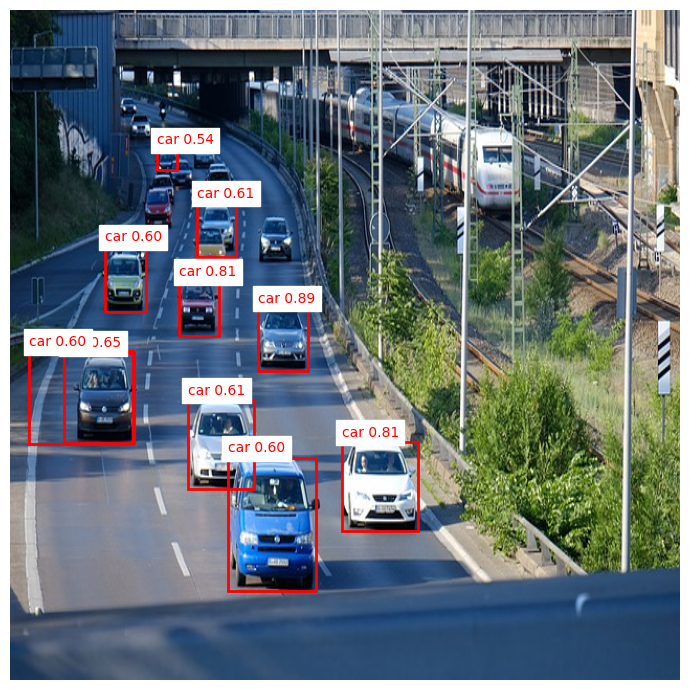

In [16]:
img = Image.open("clear (995).jpg").convert("RGB")
img_resized = img.resize((640, 640))
img_array = np.array(img_resized, dtype=np.float32) / 255.0
img_tensor = tf.expand_dims(img_array, axis=0)

predictions = model.predict(img_tensor)

boxes   = predictions["boxes"][0]
classes = predictions["classes"][0]
scores  = predictions["confidence"][0]

fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.imshow(img_resized)

for box, cls, score in zip(boxes, classes, scores):
    if score < 0.5:
        continue
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    rect = patches.Rectangle((x1, y1), w, h,
                              linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, f"{CLASS_NAMES[int(cls)]} {score:.2f}",
            color='red', fontsize=10, backgroundcolor='white')

ax.axis('off')
plt.tight_layout()
plt.show()